# `Waffle charts` , `Word Cloud`, `Seaborn`, `Folium` for GeoSpatial Data

* Waffle Charts

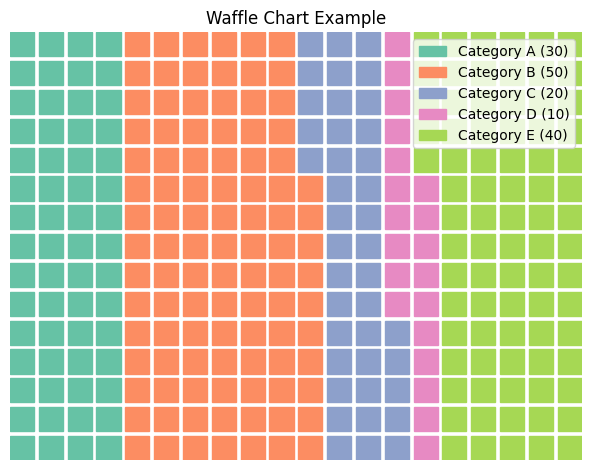

In [1]:
import matplotlib.pyplot as plt
from pywaffle import Waffle

data = {'Category A': 30, 'Category B': 50, 'Category C': 20, 'Category D': 10, 'Category E': 40}
fig = plt.figure(FigureClass=Waffle, 
                 rows=15,
                 columns=20,
                 values=data,
                 title={'label': 'Waffle Chart Example', 'loc': 'center'},
                 labels=[f"{k} ({v})" for k, v in data.items()])

plt.show()

* Word Cloud Charts

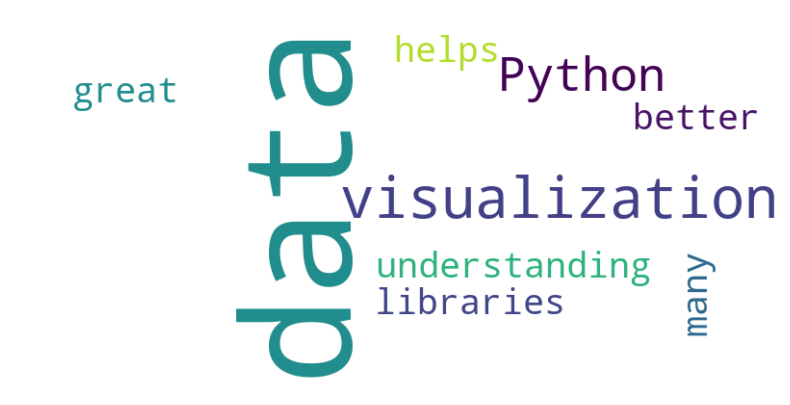

In [2]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = "Python is great for data visualization. Data visualization helps in understanding data better. Python has many libraries for data visualization."

wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

* Seaborn 

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  \
0  Adelie  Torgersen            39.1           18.7              181.0   
1  Adelie  Torgersen            39.5           17.4              186.0   
2  Adelie  Torgersen            40.3           18.0              195.0   
3  Adelie  Torgersen             NaN            NaN                NaN   
4  Adelie  Torgersen            36.7           19.3              193.0   

   body_mass_g     sex  
0       3750.0    Male  
1       3800.0  Female  
2       3250.0  Female  
3          NaN     NaN  
4       3450.0  Female  


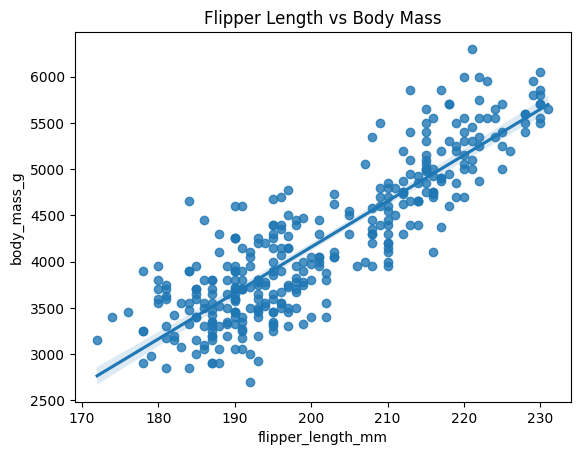

In [ ]:
import seaborn as sns

sample_data = sns.load_dataset("penguins")
print(sample_data.head())

# regplot as a kind of scatter plot with a regression line in seaborn only not in matplotlib
sns.regplot(x='flipper_length_mm', y='body_mass_g', data=sample_data)
plt.title('Flipper Length vs Body Mass')
plt.show()

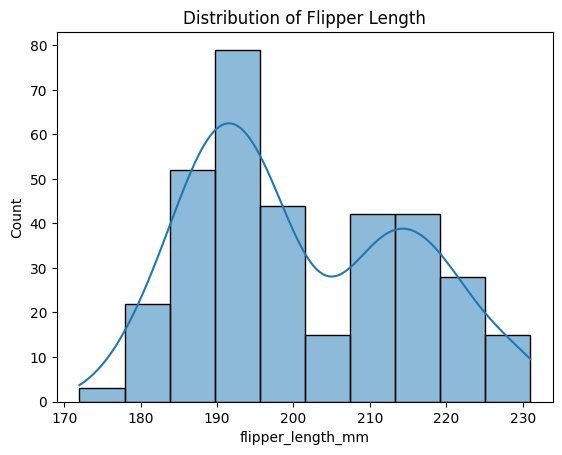

In [6]:
sns.histplot(data=sample_data, x='flipper_length_mm', kde=True)
plt.title('Distribution of Flipper Length')
plt.show()

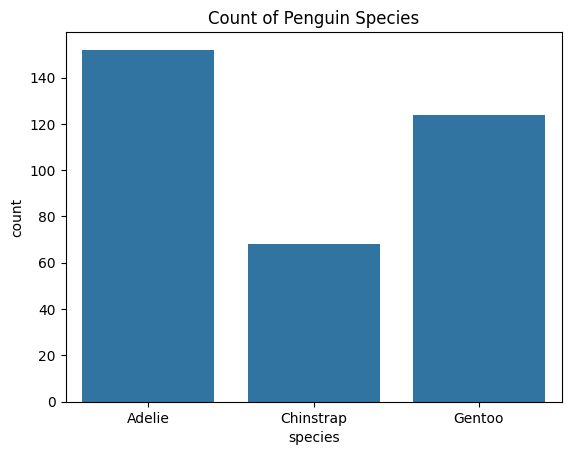

In [8]:
sns.countplot(x='species', data=sample_data)
plt.title('Count of Penguin Species')
plt.show()

* Folium

In [ ]:
import folium

# create a map centered at a specific location
m = folium.Map(location=[37.7749, -122.4194], zoom_start=10)

# add a marker to egypt
folium.Marker([30.0444, 31.2357], popup='Cairo, Ehypt').add_to(m)

# display the map
m

In [12]:
# adding multiple markers 
cities = {
    "New York": [40.7128, -74.0060],
    "Los Angeles": [34.0522, -118.2437],
    "Chicago": [41.8781, -87.6298]
}

for city, coords in cities.items():
    folium.Marker(location=coords, popup=city).add_to(m)

m

# Creating Dashboards with `Plotly`, `Dash` and `Streamlit`

* plotly

In [15]:
from plotly import express as px
from plotly import graph_objects as go
import pandas as pd

df = px.data.iris()
fig = go.Figure(data=go.Scatter(
    x=df['sepal_width'],
    y=df['sepal_length'],
    mode='markers',
    marker=dict(color=df['species_id'], 
    colorscale='Viridis', 
    showscale=True
    )
))
fig.update_layout(title='Iris Sepal Dimensions', xaxis_title='Sepal Width(cm)', yaxis_title='Sepal Length(cm)')
fig.show()

* plotly express

In [16]:
import plotly.express as px

# Load example dataset
df = px.data.gapminder().query("year == 2007")

# Create interactive scatter plot
fig = px.scatter(df, x="gdpPercap", y="lifeExp", size="pop", color="continent",
                 hover_name="country", log_x=True, size_max=60)

fig.show()


* Dash

In [ ]:
import dash
from dash import dcc, html
import plotly.express as px

# Load data
df = px.data.gapminder()

# Create app
app = dash.Dash(__name__)
app.layout = html.Div([
    html.H1("Gapminder Dashboard"),
    dcc.Dropdown(df.year.unique(), id='year-dropdown', value=2007),
    dcc.Graph(id='scatter-plot')
])

@app.callback(
    dash.Output('scatter-plot', 'figure'),
    dash.Input('year-dropdown', 'value')
)
def update_graph(selected_year):
    filtered_df = df[df.year == selected_year]
    fig = px.scatter(filtered_df, x="gdpPercap", y="lifeExp", size="pop",
                     color="continent", hover_name="country", log_x=True)
    return fig

if __name__ == '__main__':
    app.run(debug=True)


In [ ]:
import dash 
from plotly import express as px
from plotly import graph_objects as go

# this is how to create a dash app
app = dash.Dash(__name_)
app.layout = html.Div([
    html.H1("Gapminder Dashboard"),
    dcc.Dropdown(px.data.gapminder().year.unique(), id='year-dropdown', value=2007),
    dcc.Graph(id='scatter-plot')
])
if __name__ == '__main__':
    app.run_server(debug=True)
